<a href="https://colab.research.google.com/github/tameralqadi7/HouseRent-DV-/blob/main/DataVisual_House_Rent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# DATA LOADING & PREPARATION
!pip install squarify
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import squarify

sns.set_theme(style="whitegrid")


df = pd.read_csv('/content/House_Rent_Dataset .csv')

df.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [ ]:
#  VARIABLE DEFINITION & STATISTICAL SUMMARY
numerical_cols = ['Rent', 'Size', 'BHK', 'Bathroom']
categorical_cols = ['Furnishing Status', 'City', 'Area Type', 'Tenant Preferred', 'Floor', 'Area Locality', 'Point of Contact']
date_col = 'Posted On'

print("="*80)
print("1. DATASET SHAPE & STRUCTURE:")
print(f"Total Rows (Listings): {df.shape[0]}")
print(f"Total Columns (Features): {df.shape[1]}")
print("-"*80)


print("\n2. STATISTICAL SUMMARY FOR NUMERICAL COLUMNS:")
display(df[numerical_cols].describe().round(2))
print("-"*80)

print("\n3. SUMMARY FOR CATEGORICAL COLUMNS:")
display(df[categorical_cols].describe(include='O'))
print("="*80)

1. DATASET SHAPE & STRUCTURE:
Total Rows (Listings): 4746
Total Columns (Features): 12
--------------------------------------------------------------------------------

2. STATISTICAL SUMMARY FOR NUMERICAL COLUMNS:


,Rent,Size,BHK,Bathroom
count,4746.00,4746.00,4746.00,4746.00
mean,34993.45,967.49,2.08,1.97
std,78106.41,634.20,0.83,0.88
min,1200.00,10.00,1.00,1.00
25%,10000.00,550.00,2.00,1.00
50%,16000.00,850.00,2.00,2.00
75%,33000.00,1200.00,3.00,2.00
max,3500000.00,8000.00,6.00,10.00


--------------------------------------------------------------------------------

3. SUMMARY FOR CATEGORICAL COLUMNS:


,Furnishing Status,City,Area Type,Tenant Preferred,Floor,Area Locality,Point of Contact
count,4746,4746,4746,4746,4746,4746,4746
unique,3,6,3,3,480,2235,3
top,Semi-Furnished,Mumbai,Super Area,Bachelors/Family,1 out of 2,Bandra West,Contact Owner
freq,2251,972,2446,3444,379,37,3216


### ** Data Distribution Analysis**
> This section examines the shape, spread, and statistical outliers of key numerical variables.

#### **Chart 1: Univariate Price Distribution**
> This chart visualizes the baseline frequency and continuous density shape of monthly rental prices across the dataset.

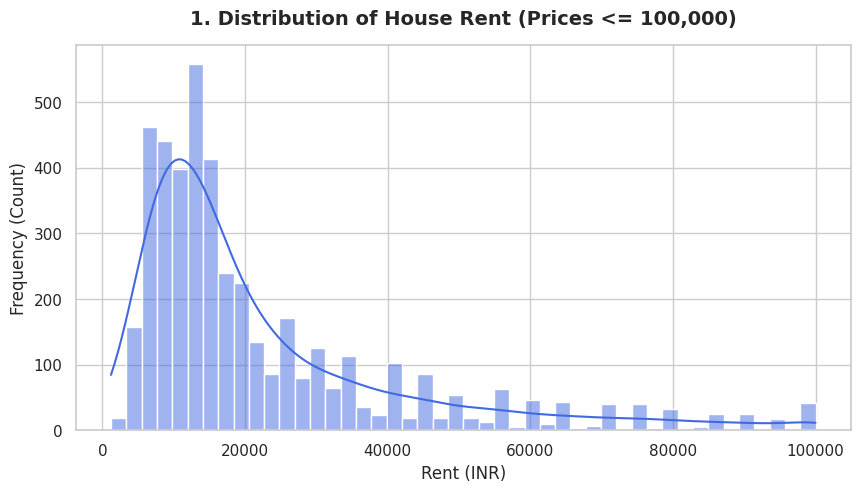


REASON FOR CHOOSING THIS CHART:
A Histogram with a KDE line is the perfect choice for showing the univariate distribution of 'Rent'.
--------------------------------------------------------------------------------
KEY FINDINGS:
- The distribution of Rent is heavily right-skewed; most prices are between 5,000 and 25,000 INR.


In [ ]:
plt.figure(figsize=(10, 5))
filtered_rent = df[df[numerical_cols[0]] <= 100000]
sns.histplot(data=filtered_rent, x=numerical_cols[0], kde=True, color='royalblue')

plt.title('1. Distribution of House Rent (Prices <= 100,000)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Rent (INR)', fontsize=12)
plt.ylabel('Frequency (Count)', fontsize=12)
plt.show()

print("\n" + "="*80)
print("REASON FOR CHOOSING THIS CHART:")
print(f"A Histogram with a KDE line is the perfect choice for showing the univariate distribution of '{numerical_cols[0]}'.")
print("-"*80)
print("KEY FINDINGS:")
print(f"- The distribution of {numerical_cols[0]} is heavily right-skewed; most prices are between 5,000 and 25,000 INR.")
print("="*80)

#### **Chart 2: Property Size Distribution Spread**
> This box plot displays the statistical median, quartiles, and extreme outliers of apartment sizes across different furnishing types.


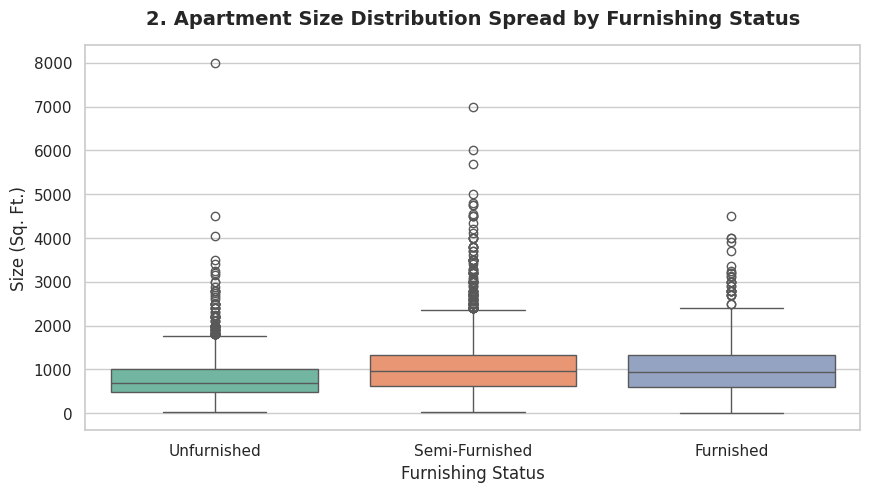


REASON FOR CHOOSING THIS CHART:
A Box Plot is chosen for split-distribution analysis to visualize data spread, median, and extreme outliers.
--------------------------------------------------------------------------------
KEY FINDINGS:
- 'Furnished' properties show a wider spread and higher median size, with significant upper-bound outliers.


In [ ]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x=categorical_cols[0],
    y=numerical_cols[1],
    palette='Set2',
    hue=categorical_cols[0],
    legend=False
)

plt.title('2. Apartment Size Distribution Spread by Furnishing Status', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Furnishing Status', fontsize=12)
plt.ylabel('Size (Sq. Ft.)', fontsize=12)
plt.show()

print("\n" + "="*80)
print("REASON FOR CHOOSING THIS CHART:")
print(f"A Box Plot is chosen for split-distribution analysis to visualize data spread, median, and extreme outliers.")
print("-"*80)
print("KEY FINDINGS:")
print(f"- 'Furnished' properties show a wider spread and higher median size, with significant upper-bound outliers.")
print("="*80)

### ** Feature Relationship & Correlation Analysis**
> This section explores interactions, trends, and correlations between multiple dataset variables.

#### **Chart 3: Rent vs Size Correlation**
> This scatter plot maps out the direct correlation pattern and pricing variance between apartment square footage and monthly rent.

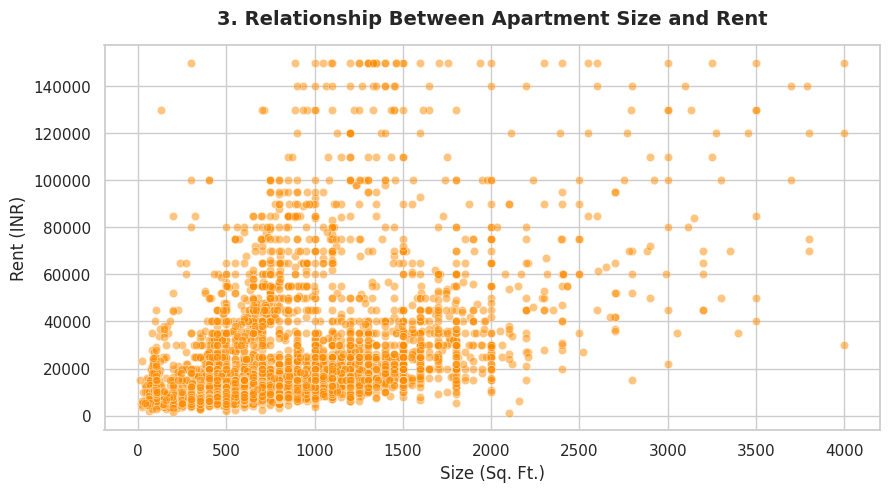


REASON FOR CHOOSING THIS CHART:
A Scatter Plot is the standard tool to visualize direct correlation between 'Size' and 'Rent'.
--------------------------------------------------------------------------------
KEY FINDINGS:
- General positive relationship: larger sizes lead to higher rents, but high vertical spread indicates variance.


In [ ]:
plt.figure(figsize=(10, 5))
filtered_df = df[(df[numerical_cols[0]] <= 150000) & (df[numerical_cols[1]] <= 4000)]
sns.scatterplot(data=filtered_df, x=numerical_cols[1], y=numerical_cols[0], alpha=0.5, color='darkorange')

plt.title('3. Relationship Between Apartment Size and Rent', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Size (Sq. Ft.)', fontsize=12)
plt.ylabel('Rent (INR)', fontsize=12)
plt.show()

print("\n" + "="*80)
print("REASON FOR CHOOSING THIS CHART:")
print(f"A Scatter Plot is the standard tool to visualize direct correlation between '{numerical_cols[1]}' and '{numerical_cols[0]}'.")
print("-"*80)
print("KEY FINDINGS:")
print(f"- General positive relationship: larger sizes lead to higher rents, but high vertical spread indicates variance.")
print("="*80)

#### **Chart 4: Rental Trends by BHK and Area Type**
> This line plot tracks how the average monthly rent price continuously scales upward based on the number of bedrooms and layout types.

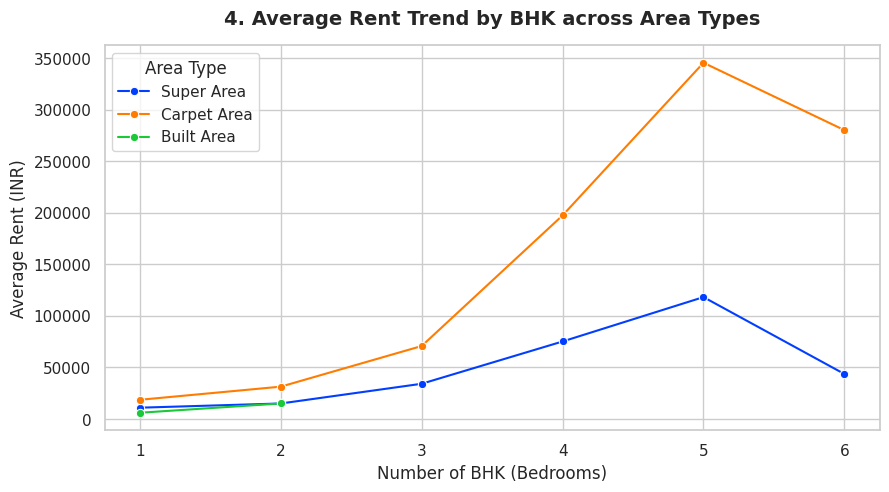


REASON FOR CHOOSING THIS CHART:
A Line Plot tracks how average 'Rent' scales continuously across 'BHK' and area categories.
--------------------------------------------------------------------------------
KEY FINDINGS:
- Consistent upward trend as BHK increases, with 'Carpet Area' showing the steepest price growth.


In [ ]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x=numerical_cols[2], y=numerical_cols[0], hue=categorical_cols[2], marker='o', errorbar=None, palette='bright')

plt.title('4. Average Rent Trend by BHK across Area Types', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of BHK (Bedrooms)', fontsize=12)
plt.ylabel('Average Rent (INR)', fontsize=12)
plt.show()

print("\n" + "="*80)
print("REASON FOR CHOOSING THIS CHART:")
print(f"A Line Plot tracks how average '{numerical_cols[0]}' scales continuously across '{numerical_cols[2]}' and area categories.")
print("-"*80)
print("KEY FINDINGS:")
print(f"- Consistent upward trend as BHK increases, with 'Carpet Area' showing the steepest price growth.")
print("="*80)

### ** Categorical Comparison Analysis**
> This section compares discrete magnitudes, volumes, and values across categorical groups.

#### **Chart 5: Geographic Rent Magnitude Ranking**
> This sorted bar chart provides an instant comparative magnitude ranking of the average monthly rental costs across different cities.

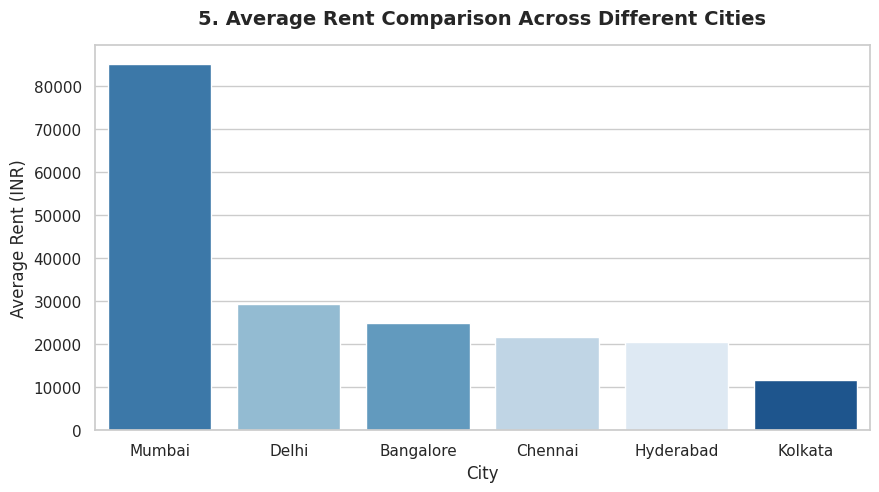


REASON FOR CHOOSING THIS CHART:
A Sorted Bar Chart allows an instant comparative magnitude ranking of average 'Rent' across cities.
--------------------------------------------------------------------------------
KEY FINDINGS:
- Mumbai records the highest average rent by a huge margin; Kolkata and Hyderabad are the most affordable.


In [ ]:
plt.figure(figsize=(10, 5))
city_order = df.groupby(categorical_cols[1])[numerical_cols[0]].mean().sort_values(ascending=False).index
sns.barplot(
    data=df,
    x=categorical_cols[1],
    y=numerical_cols[0],
    errorbar=None,
    palette='Blues_r',
    order=city_order,
    hue=categorical_cols[1],
    legend=False
)

plt.title('5. Average Rent Comparison Across Different Cities', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('City', fontsize=12)
plt.ylabel('Average Rent (INR)', fontsize=12)
plt.show()

print("\n" + "="*80)
print("REASON FOR CHOOSING THIS CHART:")
print(f"A Sorted Bar Chart allows an instant comparative magnitude ranking of average '{numerical_cols[0]}' across cities.")
print("-"*80)
print("KEY FINDINGS:")
print(f"- Mumbai records the highest average rent by a huge margin; Kolkata and Hyderabad are the most affordable.")
print("="*80)

#### **Chart 6: Market Supply Share by Tenant Preference (Pie Chart)**
> This pie chart compares the total listing volumes and market composition based on preferred tenant categories.

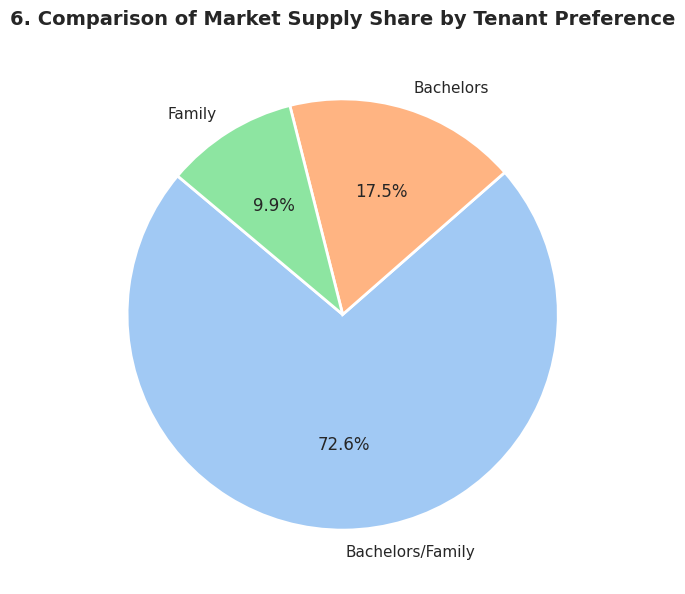


REASON FOR CHOOSING THIS CHART:
A Pie Chart is selected to compare the part-to-whole listing volumes of 'Tenant Preferred'.
--------------------------------------------------------------------------------
KEY FINDINGS:
- 'Bachelors/Family' and 'Bachelors' listings make up the vast majority of the comparative market supply.
- 'Owners' represent a minimal fraction of the preferred tenant listings.


In [ ]:
plt.figure(figsize=(7, 7))

tenant_counts = df[categorical_cols[3]].value_counts()

plt.pie(
    tenant_counts,
    labels=tenant_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('pastel', len(tenant_counts)),
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

plt.title('6. Comparison of Market Supply Share by Tenant Preference', fontsize=14, fontweight='bold', pad=15)
plt.show()

print("\n" + "="*80)
print("REASON FOR CHOOSING THIS CHART:")
print(f"A Pie Chart is selected to compare the part-to-whole listing volumes of '{categorical_cols[3]}'.")
print("-"*80)
print("KEY FINDINGS:")
print("- 'Bachelors/Family' and 'Bachelors' listings make up the vast majority of the comparative market supply.")
print("- 'Owners' represent a minimal fraction of the preferred tenant listings.")
print("="*80)

### ** Market Composition & Proportions**
> This final section examines the internal part-to-whole composition, market share ratios, and structural data volume.

#### **Chart 7: Normalized Tenant Preference Breakdown (Stacked Bar Chart)**
> This stacked bar chart normalizes values to 100% to display and compare the internal categorical composition within each city.

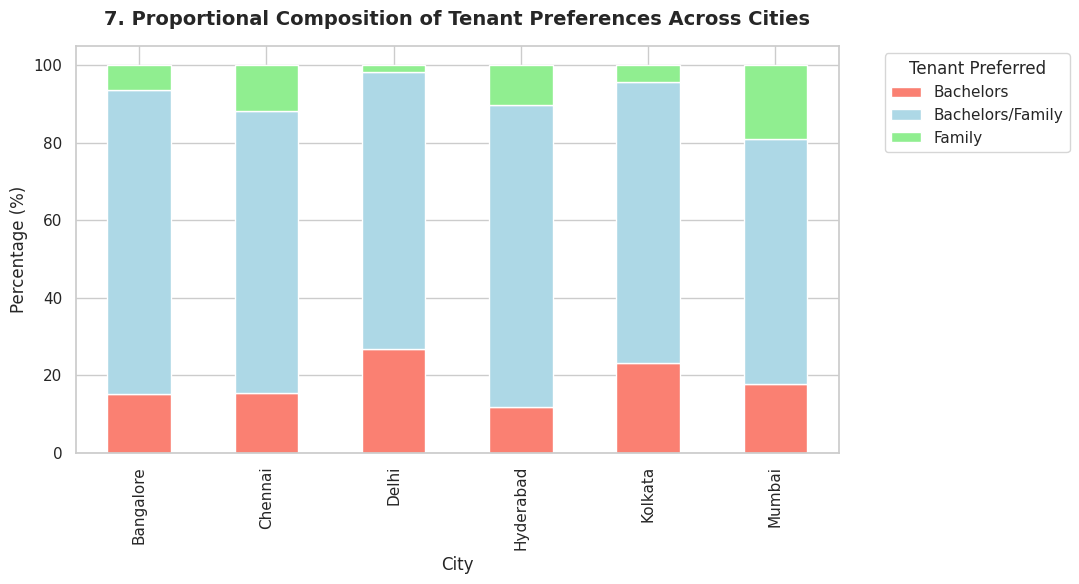


REASON FOR CHOOSING THIS CHART:
A Stacked Bar Chart normalizes variables to 100% to compare the internal structural breakdown of 'Tenant Preferred' within each city.
--------------------------------------------------------------------------------
KEY FINDINGS:
- 'Bachelors' and 'Families' combined rule almost all cities, but Mumbai/Delhi show a higher standalone share for bachelors.


In [ ]:
plt.figure(figsize=(11, 6))


composition_data = pd.crosstab(df[categorical_cols[1]], df[categorical_cols[3]], normalize='index') * 100

composition_data.plot(kind='bar', stacked=True, ax=plt.gca(), color=['salmon', 'lightblue', 'lightgreen'])

plt.title('7. Proportional Composition of Tenant Preferences Across Cities', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('City', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.legend(title='Tenant Preferred', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("REASON FOR CHOOSING THIS CHART:")
print(f"A Stacked Bar Chart normalizes variables to 100% to compare the internal structural breakdown of '{categorical_cols[3]}' within each city.")
print("-"*80)
print("KEY FINDINGS:")
print("- 'Bachelors' and 'Families' combined rule almost all cities, but Mumbai/Delhi show a higher standalone share for bachelors.")
print("="*80)

#### **Chart 8: Market Supply Comparison via Treemap Analysis (Treemap)**
> This chart utilizes a Treemap design to compare the volume of listings, mapping each area type's frequency to proportional nested rectangles.

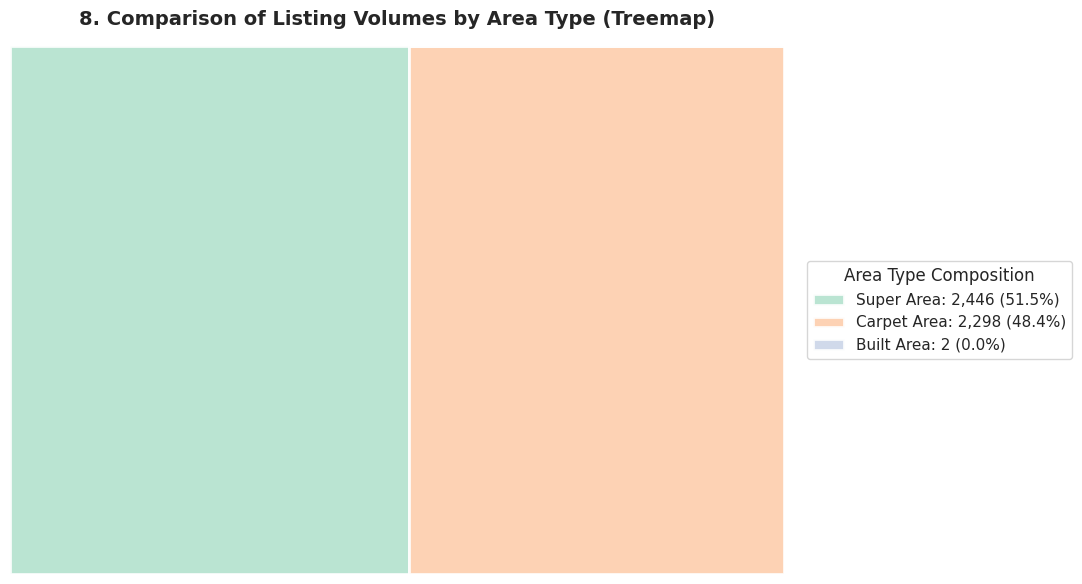


REASON FOR CHOOSING THIS CHART:
A Treemap with an external legend is selected to effectively demonstrate part-to-whole categorical composition.
Moving the text labels outside prevents visual crowding in extremely small structural components like 'Built Area'.
--------------------------------------------------------------------------------
KEY FINDINGS:
- 'Super Area' occupies the largest visual rectangle, proving its dominance in market supply composition.
- 'Carpet Area' takes the second largest block, while 'Built Area' is squeezed into a tiny slice due to its rarity.


In [ ]:
plt.figure(figsize=(11, 6))

area_counts = df[categorical_cols[2]].value_counts().reset_index()
area_counts.columns = ['Area Type', 'Count']

total_listings = area_counts['Count'].sum()
area_counts['Percentage'] = (area_counts['Count'] / total_listings) * 100

legend_labels = [
    f"{row['Area Type']}: {row['Count']:,} ({row['Percentage']:.1f}%)"
    for _, row in area_counts.iterrows()
]

colors = sns.color_palette('Pastel2', len(area_counts))
shapes = squarify.plot(
    sizes=area_counts['Count'],
    color=colors,
    alpha=0.9,
    edgecolor='white',
    linewidth=2
)

plt.legend(
    handles=shapes.patches,
    labels=legend_labels,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    title="Area Type Composition",
    title_fontsize=12,
    fontsize=11,
    frameon=True
)

plt.title('8. Comparison of Listing Volumes by Area Type (Treemap)', fontsize=14, fontweight='bold', pad=15)
plt.axis('off')
plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("REASON FOR CHOOSING THIS CHART:")
print(f"A Treemap with an external legend is selected to effectively demonstrate part-to-whole categorical composition.")
print(f"Moving the text labels outside prevents visual crowding in extremely small structural components like 'Built Area'.")
print("-"*80)
print("KEY FINDINGS:")
print("- 'Super Area' occupies the largest visual rectangle, proving its dominance in market supply composition.")
print("- 'Carpet Area' takes the second largest block, while 'Built Area' is squeezed into a tiny slice due to its rarity.")
print("="*80)